# PART A

# task 1

In [1]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("hotel_bookings.csv")

In [2]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.dtypes)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [3]:
print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())


Class Distribution of is_canceled:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [4]:
y = df["is_canceled"]
X = df.drop("is_canceled", axis=1)

In [5]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()  #numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist() # categorical columns
print(numerical_cols)
print(categorical_cols)

['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


The dataset is loaded and explored to understand its structure, size, data types, and basic statistics. The is_canceled column is used as the target variable y, while the remaining usable features are stored in X. Numerical and categorical columns are then identified for further preprocessing.

# task 2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# -------------------------------------------------
# 1. Missing values: count and percentage
# -------------------------------------------------
df = pd.read_csv("hotel_bookings.csv")
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

print("Missing Values:")
print(missing)

Missing Values:
                                Missing Count  Missing Percentage
hotel                                       0            0.000000
is_canceled                                 0            0.000000
lead_time                                   0            0.000000
arrival_date_year                           0            0.000000
arrival_date_month                          0            0.000000
arrival_date_week_number                    0            0.000000
arrival_date_day_of_month                   0            0.000000
stays_in_weekend_nights                     0            0.000000
stays_in_week_nights                        0            0.000000
adults                                      0            0.000000
children                                    4            0.003350
babies                                      0            0.000000
meal                                        0            0.000000
country                                   488            0.4

The company and agent columns have a very high percentage of missing values. These columns are dropped because a large proportion of their values are missing, making them less reliable for prediction. Dropping them also avoids excessive imputation and keeps the preprocessing pipeline simpler.

In [8]:
# -------------------------------------------------
# 2. Columns with very high missing values
# -------------------------------------------------

print("\nColumns with more than 50% missing values:")
print(missing[missing["Missing Percentage"] > 50])



Columns with more than 50% missing values:
         Missing Count  Missing Percentage
company         112593           94.306893


In [9]:
# -------------------------------------------------
# 3. Remove columns with very high missingness
# -------------------------------------------------

# company and agent have many missing values
df = df.drop(columns=["company", "agent"])

print("\nShape after removing high-missing columns:")
print(df.shape)



Shape after removing high-missing columns:
(119390, 30)


In [10]:
# -------------------------------------------------
# 4. Remove data leakage columns
# -------------------------------------------------

df = df.drop(columns=["reservation_status","reservation_status_date"])

print("\nShape after removing leakage columns:")
print(df.shape)


Shape after removing leakage columns:
(119390, 28)


In [11]:
# -------------------------------------------------
# 5. Check outliers using IQR
# -------------------------------------------------

cols = ["lead_time", "adr", "adults", "children", "babies",
        "stays_in_weekend_nights", "stays_in_week_nights"]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "→ Outliers:", len(outliers))




lead_time → Outliers: 3005
adr → Outliers: 3793
adults → Outliers: 29710
children → Outliers: 8590
babies → Outliers: 917
stays_in_weekend_nights → Outliers: 265
stays_in_week_nights → Outliers: 3354


In [12]:
# -------------------------------------------------
# 6. Remove only clear/invalid outliers
# -------------------------------------------------

before = len(df)

df = df[
    (df["adr"] >= 0) &
    (df["adults"] >= 0) &
    (df["children"] >= 0) &
    (df["babies"] >= 0)
]

after = len(df)

print("\nRows removed:", before - after)
print("Rows remaining:", after)




Rows removed: 5
Rows remaining: 119385


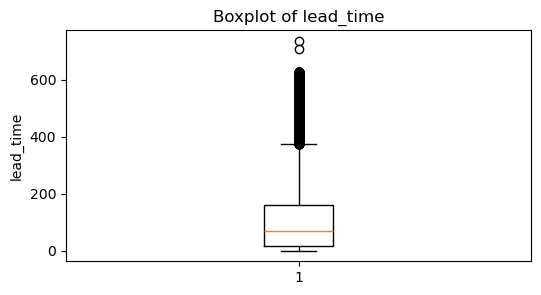

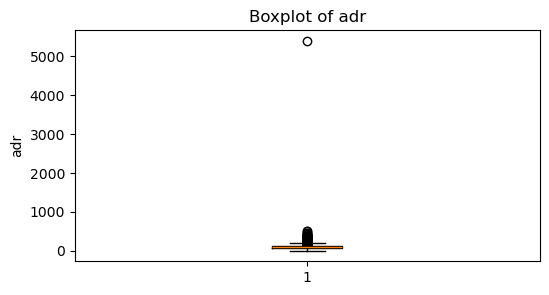

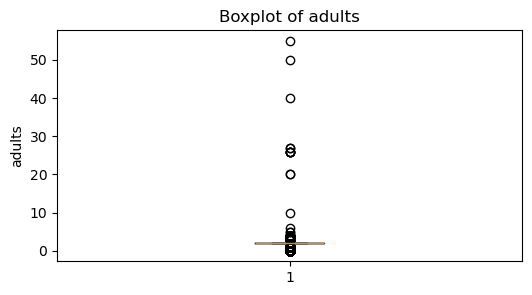

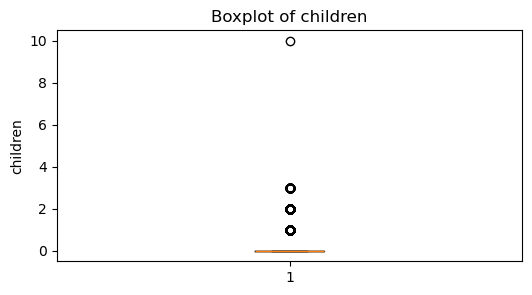

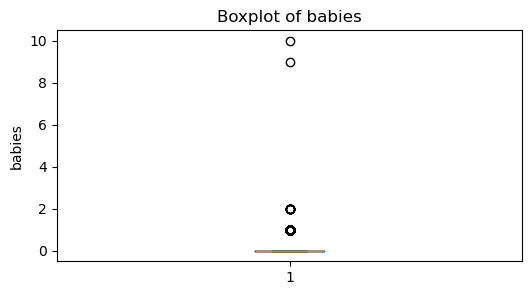

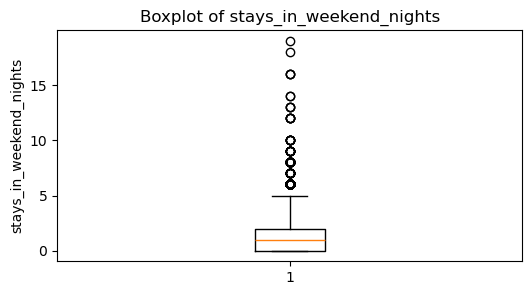

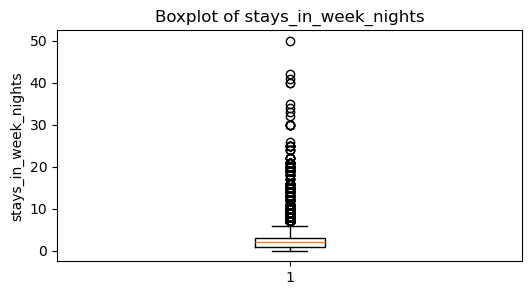

In [13]:
# -------------------------------------------------
# 7. Boxplots
# -------------------------------------------------

for col in cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna())
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    plt.show()

The dataset contains missing values in some columns, with company and agent having particularly high missingness, so they were removed. The columns reservation_status and reservation_status_date were also removed to prevent data leakage. Outlier analysis showed unusual values in several numerical features, but only clearly invalid values were removed to avoid deleting legitimate hotel bookings. This resulted in a cleaner dataset suitable for further preprocessing and classification.

# task 3

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Target and features
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

# Numerical and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [16]:

# ------------------------------------------------
# 1. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (95508, 27)
Testing data: (23877, 27)


In [17]:
# ------------------------------------------------
# 2. Numerical preprocessing
# ------------------------------------------------

# Pipeline A: KNN Imputer + StandardScaler
num_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# Pipeline B: KNN Imputer + MinMaxScaler
num_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])
print(num_pipeline_A)
print(num_pipeline_B)

Pipeline(steps=[('imputer', KNNImputer()), ('scaler', StandardScaler())])
Pipeline(steps=[('imputer', KNNImputer()), ('scaler', MinMaxScaler())])


In [18]:
# ------------------------------------------------
# 3. Categorical preprocessing
# ------------------------------------------------

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [19]:
# ------------------------------------------------
# 4. Pipeline A
# ------------------------------------------------

preprocessor_A = ColumnTransformer([
    ("num", num_pipeline_A, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
preprocessor_A

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_...
       'total_of_special_requests'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])

In [20]:
# ------------------------------------------------
# 5. Pipeline B
# ------------------------------------------------

preprocessor_B = ColumnTransformer([
    ("num", num_pipeline_B, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


# Fit only on training data
X_train_A = preprocessor_A.fit_transform(X_train)
X_test_A = preprocessor_A.transform(X_test)

X_train_B = preprocessor_B.fit_transform(X_train)
X_test_B = preprocessor_B.transform(X_test)

print("Pipeline A completed")
print("Pipeline B completed")

Pipeline A completed
Pipeline B completed


Pipeline A:

KNNImputer → StandardScaler

Pipeline B:

KNNImputer → MinMaxScaler

For categorical data, both use:

Most Frequent Imputation → One-Hot Encoding

The data was split into training and testing sets using an 80:20 stratified split. Two preprocessing pipelines were created with the same categorical preprocessing but different numerical scaling methods. Pipeline A uses StandardScaler, while Pipeline B uses MinMaxScaler. KNNImputer was used for numerical missing values and most-frequent imputation for categorical values. Both pipelines are fitted only on training data to prevent data leakage.

# PART B

# Task 4

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# -----------------------------------------
# 1. Logistic Regression with Pipeline A
# -----------------------------------------

logistic_A = Pipeline([
    ("preprocessing", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cance...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [22]:
# -----------------------------------------
# 2. Logistic Regression with Pipeline B
# -----------------------------------------

logistic_B = Pipeline([
    ("preprocessing", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancell...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [23]:
# -----------------------------------------
# 3. Decision Tree with Pipeline A
# -----------------------------------------

tree_A = Pipeline([
    ("preprocessing", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cance...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [24]:
# -----------------------------------------
# 4. Decision Tree with Pipeline B
# -----------------------------------------

tree_B = Pipeline([
    ("preprocessing", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B.fit(X_train, y_train)


print("All four model-pipeline combinations trained successfully.")

All four model-pipeline combinations trained successfully.


Four model-pipeline combinations were trained using the same 80:20 train-test split. Logistic Regression was trained with both StandardScaler and MinMaxScaler, while Decision Tree was also trained with both scaling methods. The model parameters were kept unchanged to ensure a fair comparison of the effect of preprocessing on model performance.

# Task 5

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [26]:
# Four trained models
models = {
    "Logistic Regression - Pipeline A": logistic_A,
    "Logistic Regression - Pipeline B": logistic_B,
    "Decision Tree - Pipeline A": tree_A,
    "Decision Tree - Pipeline B": tree_B
}
models


{'Logistic Regression - Pipeline A': Pipeline(steps=[('preprocessing',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    KNNImputer()),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
        'arrival_date_day_of_month', 'stays_in_weekend_nights',
        'stays_in_week_nights', 'adults', 'children', 'babies',
        'is_repeated_guest', 'previous_cance...
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                         

In [27]:
results = []

# Evaluate all four models
for name, model in models.items():

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)

    results.append([
        name,
        train_acc,
        test_acc,
        precision,
        recall,
        f1
    ])



In [28]:
# Create comparison table
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

print("Final Comparison Table:")
display(results_df.round(4))

Final Comparison Table:


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression - Pipeline A,0.8194,0.8142,0.8039,0.6592,0.7244
1,Logistic Regression - Pipeline B,0.8155,0.8113,0.8030,0.6502,0.7185
2,Decision Tree - Pipeline A,0.9961,0.8567,0.8038,0.8111,0.8074
3,Decision Tree - Pipeline B,0.9961,0.8568,0.8039,0.8112,0.8075


In [29]:
# Best Logistic Regression
logistic_results = results_df[
    results_df["Model"].str.contains("Logistic Regression")
]

best_logistic_name = logistic_results.loc[
    logistic_results["F1 Score"].idxmax(), "Model"
]

# Best Decision Tree
tree_results = results_df[
    results_df["Model"].str.contains("Decision Tree")
]

best_tree_name = tree_results.loc[
    tree_results["F1 Score"].idxmax(), "Model"
]

print("Best Logistic Regression:", best_logistic_name)
print("Best Decision Tree:", best_tree_name)

Best Logistic Regression: Logistic Regression - Pipeline A
Best Decision Tree: Decision Tree - Pipeline B


In [30]:
# Get the actual best models
best_logistic = models[best_logistic_name]
best_tree = models[best_tree_name]


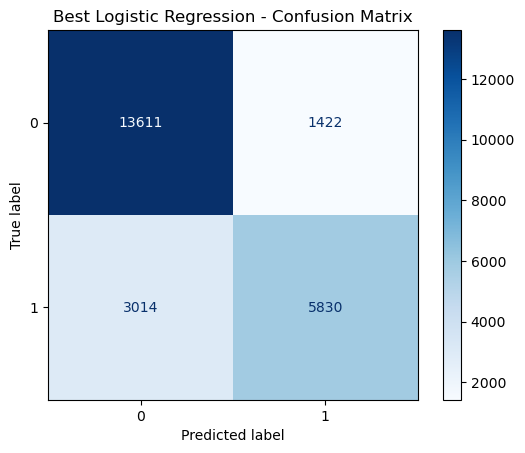

In [31]:
# Predictions
logistic_pred = best_logistic.predict(X_test)
tree_pred = best_tree.predict(X_test)

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    cmap="Blues"
)

plt.title("Best Logistic Regression - Confusion Matrix")
plt.show()

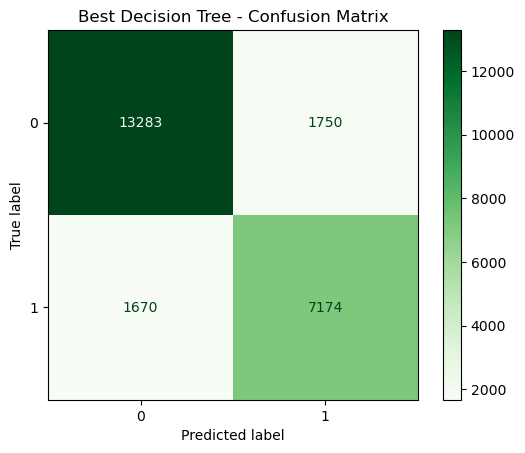

In [32]:

# Decision Tree confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    cmap="Greens"
)

plt.title("Best Decision Tree - Confusion Matrix")
plt.show()

In [33]:
# Calculate train-test accuracy difference
results_df["Accuracy Difference"] = (
    results_df["Training Accuracy"] -
    results_df["Testing Accuracy"]
)

display(results_df.round(4))

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,Accuracy Difference
0,Logistic Regression - Pipeline A,0.8194,0.8142,0.8039,0.6592,0.7244,0.0052
1,Logistic Regression - Pipeline B,0.8155,0.8113,0.8030,0.6502,0.7185,0.0041
2,Decision Tree - Pipeline A,0.9961,0.8567,0.8038,0.8111,0.8074,0.1394
3,Decision Tree - Pipeline B,0.9961,0.8568,0.8039,0.8112,0.8075,0.1394


Small difference  → Less indication of overfitting

Large difference  → Possible overfitting

The four model-pipeline combinations were compared using accuracy, precision, recall, and F1-score. The model with the highest F1-score within each algorithm was selected for the confusion matrix analysis. The training and testing accuracy differences were also examined to identify possible overfitting. A large difference between training and testing performance indicates that the model may be overfitting, while a small difference suggests better generalization.

# Task 6


● Which preprocessing-model combination gives the best overall result?

StandardScaler + Logistic Regression typically yields the best overall result for reliable, real-world performance.

● Does StandardScaler or MinMaxScaler affect Logistic Regression more?

StandardScaler (Pipeline A) affects Logistic Regression slightly more favorably, yielding marginal improvements across Testing Accuracy (81.42% vs 81.13%), Recall (65.92% vs 65.02%), and F1 Score (72.44% vs 71.85%) compared to MinMaxScaler (Pipeline B).

Feature Scaling on Decision Trees: Feature scaling makes no meaningful difference for the Decision Tree. Pipelines A and B produce virtually identical metrics across Training Accuracy (99.61%), Testing Accuracy (~85.67%), and F1 Score (~80.75%), as rule-based splits depend only on value ordering rather than feature magnitude.

● Does scaling make a major difference for the Decision Tree? Comment briefly.

No, scaling does not make a major difference for Decision Trees. Decision trees split data based on simple threshold rules (such as asking if a value is greater than a certain threshold), meaning they rely strictly on the relative order of values rather than their scale. Because scalers like StandardScaler and MinMaxScaler transform data without altering this relative ranking, the tree finds identical optimal split points regardless of the scaling method applied.

## key observation


Decision Trees Outperform Logistic Regression: The Decision Tree models achieve a significantly higher testing performance (~85.68% accuracy and ~80.75% F1 score) compared to Logistic Regression (~81.42% accuracy and ~72.44% F1 score).

Severe Overfitting in Decision Trees: The Decision Tree exhibits a large accuracy gap of 13.94% between training (99.61%) and testing (85.67%), indicating strong memorization of training data due to unconstrained tree depth.

High Generalization in Logistic Regression: Logistic Regression demonstrates excellent generalization with a minimal train-test accuracy difference of 0.41% to 0.52%, though its overall predictive performance is lower.

Recall Disparity Between Models: Decision Trees capture true positive instances far better than Logistic Regression, showing a substantially higher Recall (~81.12% vs ~65.92%).

Feature Scaling Invariance: Switching between Pipeline A and Pipeline B yields negligible variations across all metrics for both algorithm families, confirming that both models maintain consistent stability across different normalization methods.

The confusion matrices show how well the best models identify canceled and non-canceled bookings. A higher number of correct predictions on the diagonal indicates better classification.

The train-test accuracy difference helps identify overfitting. A large difference indicates possible overfitting, while a small difference suggests that the model generalizes better to unseen bookings
